### Importing libraries and creates constants

In [1]:
import catboost
from catboost import datasets, metrics
from catboost import *

from image_processing import read_img,show_img
from ml_utilitis import extract_features,extract_label,save_model,predict_full_image,remove_small_components
from simple_statistics import create_confusions_matrix
from image_processing import preproces_pipeline,postproces_pipeline
import os
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"

KERNEL_SIZE:int=5

from catboost.utils import get_gpu_device_count

device:str="GPU" if get_gpu_device_count()>0 else "CPU"

In [2]:
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

data=list(zip(input_images,manual_images,mask_images))

print(f"Total number of images: {len(data)}")
max_test_id=int(len(data)*0.80)
print(f"Number of images used to train the model: {max_test_id}")

Total number of images: 45
Number of images used to train the model: 36


### Colecting feauters and labels to training

In [3]:
all_features=[]
all_labels=[]
for idx,element in enumerate(data):
    img=read_img(element[0])
    img=preproces_pipeline(img,11)

    manual_=read_img(element[1])
    manual_=manual_[:,:,1]
    manual_=np.where(manual_>0,1,0)

    mask_=read_img(element[2])

    max_x,max_y=img.shape
    center_x,center_y=max_x//2,max_y//2

    half = KERNEL_SIZE // 2

    for x in range(half,max_x-half):

        for y in range(half,max_y-half):
            #Only point in the FOV are important
            if mask_[x,y,1]==0:
                continue
            patch = img[x-half:x+half+1,y-half:y+half+1]

            label_patch = manual_[x-half:x+half+1,y-half:y+half+1]

            features_sample = extract_features(patch)

            all_features.append(features_sample)

            all_labels.append(
                extract_label(label_patch, KERNEL_SIZE)
            )
            #Max number of samples from a single image is equal to 25 000 points
            if len(all_features)>(idx+1)*50_000:
                break
        if idx>=max_test_id:
            break

In [4]:
pool1 = Pool(data=all_features, label=all_labels)
X_train, X_validation, y_train, y_validation = train_test_split(all_features, all_labels, train_size=0.75, random_state=42)

In [5]:
random_under_sampler=RandomUnderSampler(sampling_strategy=1.0,random_state=42)
X_train,y_train=random_under_sampler.fit_resample(X_train,y_train)
print(f"Number of positive values in the training data set: {y_train.count(1)}")
print(f"Number of negative values in the training data set: {y_train.count(0)}")

Number of positive values in the training data set: 96910
Number of negative values in the training data set: 96910


In [15]:
model = CatBoostClassifier(
    iterations=1_025,
    random_seed=42,
    learning_rate=0.075,
     task_type=device
)
model.fit(
    X_train, y_train,
    eval_set=(X_validation, y_validation),
    logging_level='Silent'
)
print('Model is fitted: ' + str(model.is_fitted()))
print('Model params:')
print(model.get_params())
print(model.best_iteration_)
print(model.best_score_)

Model is fitted: True
Model params:
{'iterations': 1025, 'learning_rate': 0.075, 'random_seed': 42, 'task_type': 'GPU'}
1023
{'learn': {'Logloss': 0.4805610956686616}, 'validation': {'Logloss': 0.4799097494064572}}


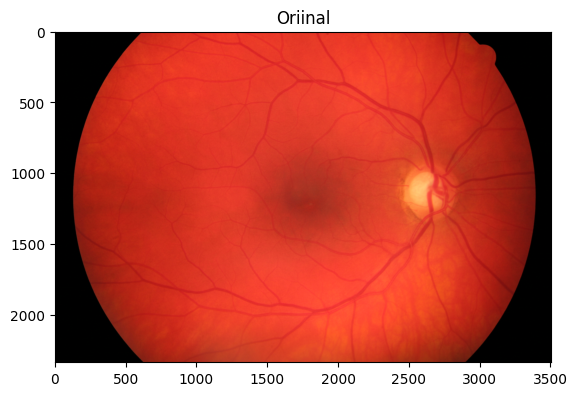

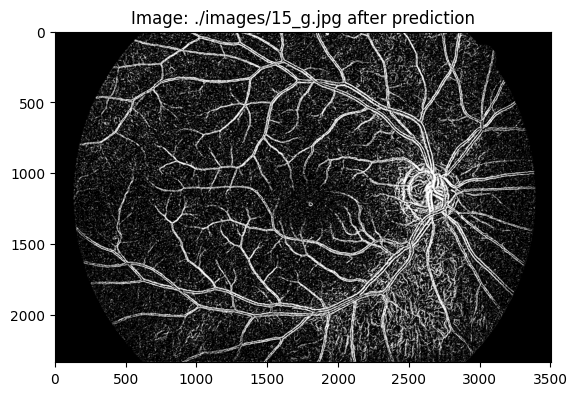

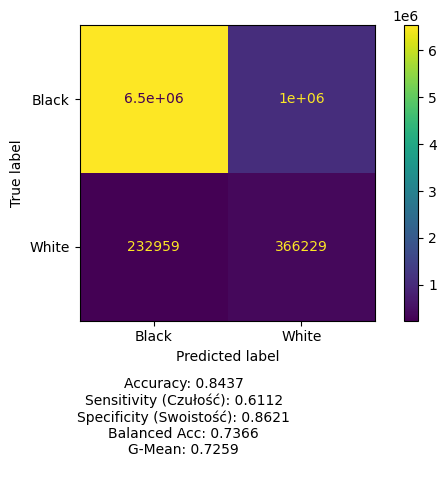

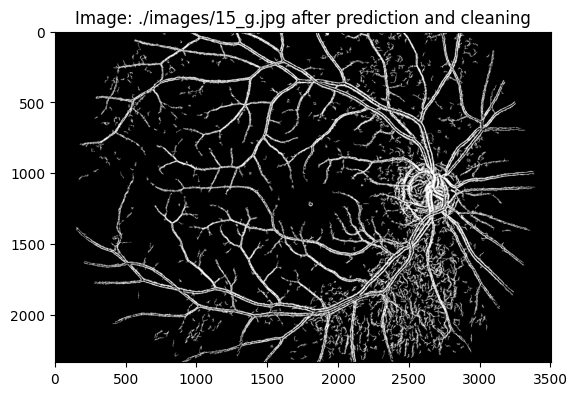

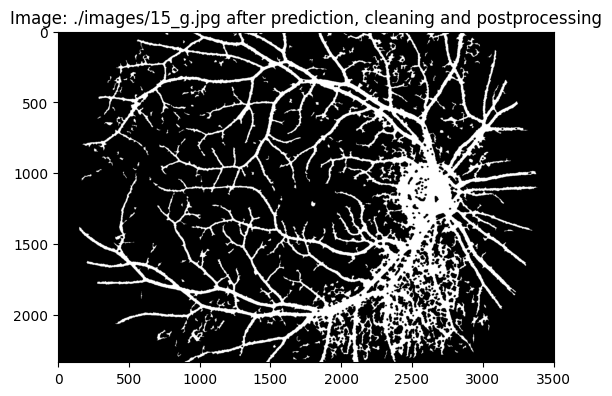

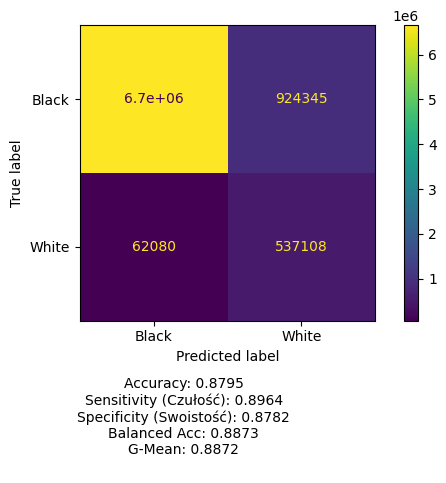

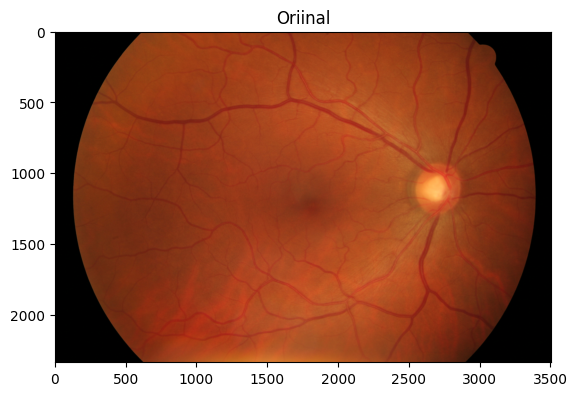

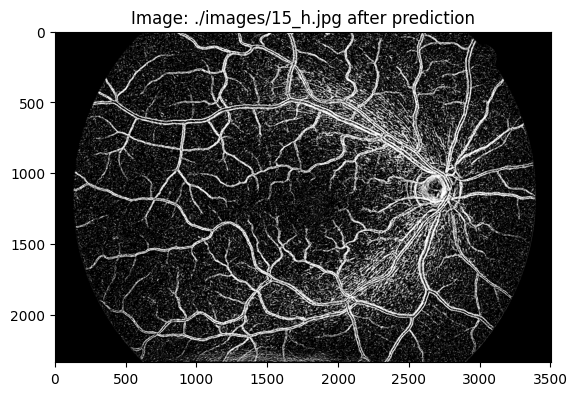

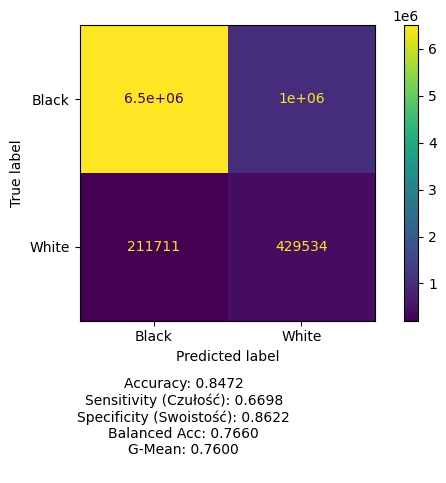

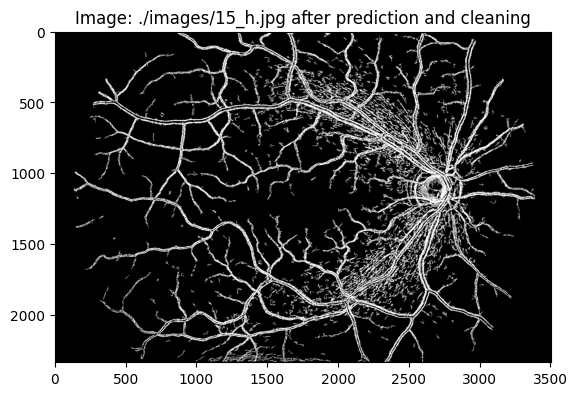

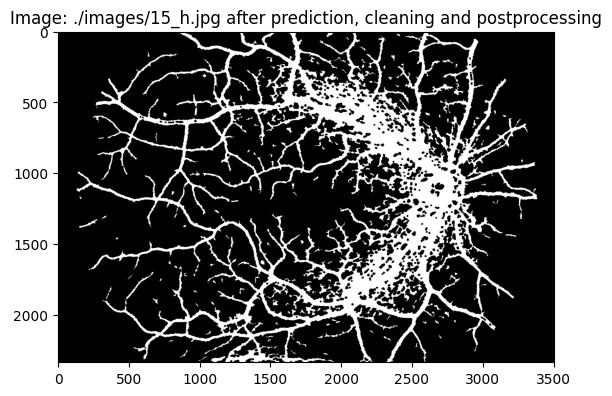

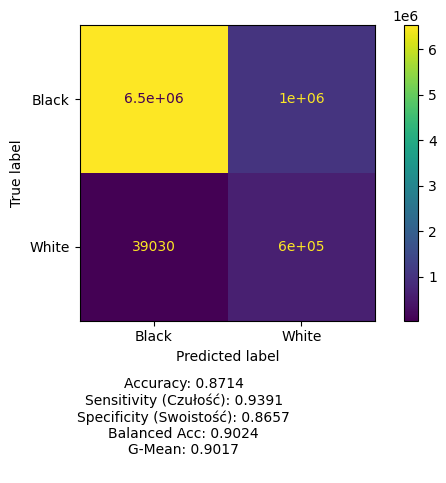

In [16]:
for idx,element in enumerate (list(data)[-2::]):
    img=read_img(element[0])
    manual=read_img(element[1])
    mask=read_img(element[2])
    show_img(img,"Oriinal")

    returned_img=predict_full_image(img,mask,model,preproces_pipeline,use_gpu=True)
    show_img(returned_img,f"Image: {element[0]} after prediction")

    manual=manual[:,:,1]
    manual=np.where(manual>0,1,0)
    
    create_confusions_matrix(manual,returned_img)
    
    cleaned=remove_small_components(returned_img,100)
    show_img(cleaned,f"Image: {element[0]} after prediction and cleaning")
    cleaned=postproces_pipeline(cleaned,13)
    
    show_img(cleaned,f"Image: {element[0]} after prediction, cleaning and postprocessing")
    create_confusions_matrix(manual,cleaned)

    if idx>2:
        break